In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)

In [5]:
# ROBUST DATA LOADING

import pandas as pd

dataset_loaded = False

urls = [

    # Backup URL 1
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx",

    # Backup URL 2
    "https://raw.githubusercontent.com/akmand/datasets/master/online_retail.xlsx",

]

for url in urls:
    try:
        print(f"Trying: {url}")

        # Read Excel dataset
        df = pd.read_excel(url)

        dataset_loaded = True

        print("\nDataset Loaded Successfully!")
        print("Dataset Shape:", df.shape)

        break

    except Exception as e:
        print(f"Failed: {e}")

if not dataset_loaded:
    raise Exception("All dataset sources failed.")

Trying: https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx

Dataset Loaded Successfully!
Dataset Shape: (541909, 8)


In [6]:
# BASIC CLEANING

df.columns = df.columns.str.lower().str.replace(" ", "_")

# Remove null customer ids
df = df[df['customerid'].notna()]

# Remove cancelled invoices
df = df[
    ~df['invoiceno']
    .astype(str)
    .str.startswith('C')
]

# Remove invalid quantities/prices
df = df[df['quantity'] > 0]
df = df[df['unitprice'] > 0]

In [7]:
# FEATURE ENGINEERING

# Revenue column
df['total_revenue'] = (
    df['quantity'] * df['unitprice']
)

# Date conversion
df['invoicedate'] = pd.to_datetime(
    df['invoicedate']
)

# Month extraction
df['month'] = (
    df['invoicedate']
    .dt.month_name()
)

# Customer purchase frequency
purchase_freq = (
    df.groupby('customerid')['invoiceno']
    .nunique()
    .reset_index()
)

purchase_freq.columns = [
    'customerid',
    'purchase_frequency'
]

df = df.merge(
    purchase_freq,
    on='customerid',
    how='left'
)

In [8]:
# CUSTOMER SEGMENTATION

def customer_segment(x):

    if x >= 20:
        return "High Value"

    elif x >= 10:
        return "Medium Value"

    else:
        return "Low Value"

df['customer_segment'] = (
    df['purchase_frequency']
    .apply(customer_segment)
)

In [9]:
# KPI REPORTING

total_customers = (
    df['customerid'].nunique()
)

total_orders = (
    df['invoiceno'].nunique()
)

total_revenue = round(
    df['total_revenue'].sum(),
    2
)

avg_order_value = round(
    total_revenue / total_orders,
    2
)

print("\n==========================")
print("BUSINESS KPI REPORT")
print("==========================")

print(f"Total Customers: {total_customers}")
print(f"Total Orders: {total_orders}")
print(f"Total Revenue: ${total_revenue}")
print(f"Average Order Value: ${avg_order_value}")



BUSINESS KPI REPORT
Total Customers: 4338
Total Orders: 18532
Total Revenue: $8911407.9
Average Order Value: $480.87


In [10]:
# SEGMENT ANALYSIS

segment_summary = (
    df.groupby('customer_segment')
    .agg(
        customers=('customerid', 'nunique'),
        revenue=('total_revenue', 'sum')
    )
    .reset_index()
)

print("\nCustomer Segment Summary:\n")
print(segment_summary)



Customer Segment Summary:

  customer_segment  customers      revenue
0       High Value        107  2907930.810
1        Low Value       3947  4343425.024
2     Medium Value        284  1660052.070


In [11]:
# MONTHLY ANALYSIS

monthly_sales = (
    df.groupby('month')
    .agg(
        revenue=('total_revenue', 'sum'),
        orders=('invoiceno', 'nunique')
    )
    .reset_index()
)

print("\nMonthly Sales:\n")
print(monthly_sales)


Monthly Sales:

        month      revenue  orders
0       April   469200.361    1149
1      August   645343.900    1280
2    December  1090906.680    2178
3    February   447137.350     997
4     January   569445.040     987
5        July   600091.011    1331
6        June   661213.690    1393
7       March   595500.760    1321
8         May   678594.560    1555
9    November  1161817.380    2657
10    October  1039318.790    1929
11  September   952838.382    1755


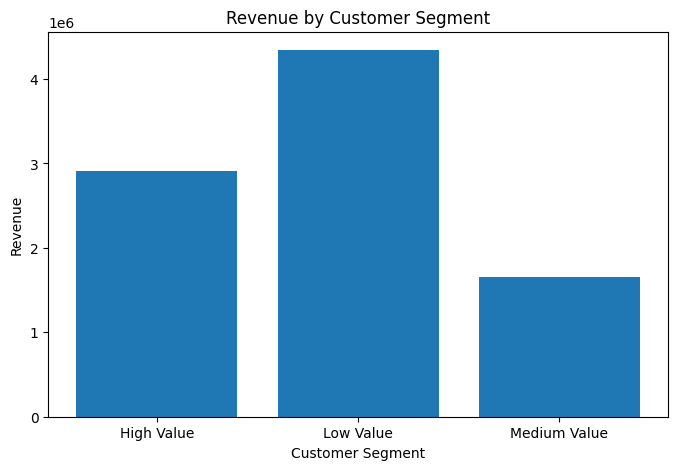

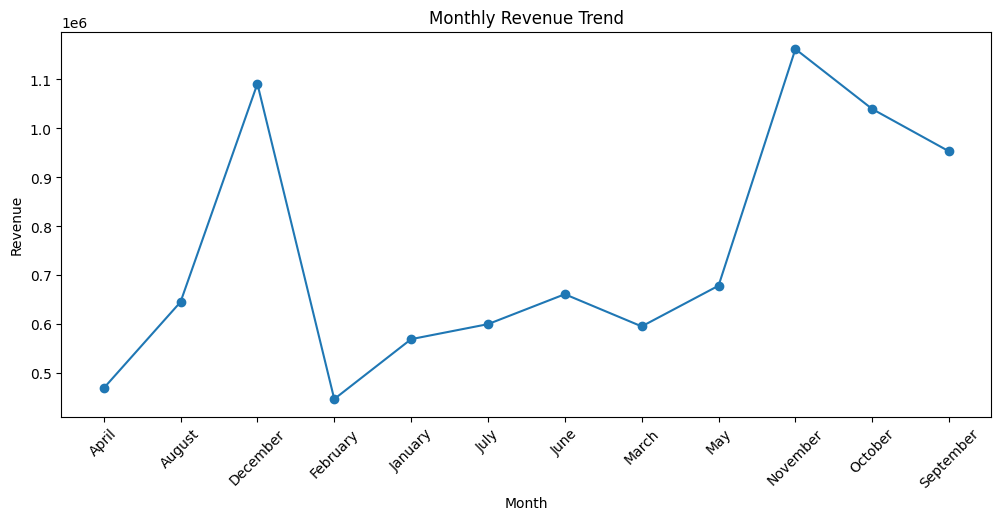

In [12]:
# VISUALIZATIONS

import matplotlib.pyplot as plt

# Revenue by Segment
plt.figure(figsize=(8,5))

plt.bar(
    segment_summary['customer_segment'],
    segment_summary['revenue']
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")

plt.show()

# Monthly Revenue Trend
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['month'],
    monthly_sales['revenue'],
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

In [13]:
# EXPORT REPORTS

segment_summary.to_csv(
    "customer_segment_summary.csv",
    index=False
)

monthly_sales.to_csv(
    "monthly_sales_report.csv",
    index=False
)

print("\nReports Exported Successfully!")


Reports Exported Successfully!
